In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
df = pd.read_csv('facebook_ads_data (2.0).csv')
df.head()


,ad_date,campaign_name,total_spend,total_impressions,total_clicks,total_value,cpc,cpm,ctr,romi
0,2022-11-05,Expansion,0.00,0,0,0.00,NaN,NaN,NaN,NaN
1,2022-11-01,Expansion,0.00,0,0,0.00,NaN,NaN,NaN,NaN
2,2022-10-31,Expansion,227.45,6054,58,191.87,3.92,37.57,0.009580,0.843570
3,2022-10-30,Expansion,335.91,27562,69,472.61,4.87,12.19,0.002503,1.406954
4,2022-10-29,Expansion,714.03,33358,115,680.34,6.21,21.41,0.003447,0.952817


In [47]:
df.groupby('campaign_name', observed = True)['total_spend'].max().sort_values(ascending = False).reset_index()

,campaign_name,total_spend
0,Expansion,2035.49
1,Lookalike,1247.61
2,Electronics,438.23
3,Hobbies,262.51
4,Wholesale,230.75
5,Discounts,142.70
6,Promos,120.00
7,Trendy,109.50
8,New items,73.11
9,Crazy discounts,36.08


In [48]:
df.describe()

,total_spend,total_impressions,total_clicks,total_value,cpc,cpm,ctr,romi
count,1494.000000,1494.000000,1494.000000,1494.000000,1443.000000,1462.000000,1462.000000,1462.000000
mean,131.035964,34190.182062,318.840696,165.457450,0.814712,5.085677,0.011947,1.326322
std,214.968986,44433.507387,485.663099,274.764573,1.705224,8.107076,0.013192,0.343012
min,0.000000,0.000000,0.000000,0.000000,0.010000,0.050000,0.000000,0.751445
25%,18.047500,8377.000000,62.250000,24.350000,0.170000,1.500000,0.004462,1.067832
50%,48.515000,15983.000000,148.000000,65.460000,0.350000,2.775000,0.007845,1.299482
75%,161.790000,45849.750000,371.750000,196.595000,0.765000,5.275000,0.015005,1.527423
max,2035.490000,456481.000000,6199.000000,2562.600000,24.790000,114.150000,0.159223,2.486911


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1494 entries, 0 to 1493
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ad_date            1494 non-null   object 
 1   campaign_name      1494 non-null   object 
 2   total_spend        1494 non-null   float64
 3   total_impressions  1494 non-null   int64  
 4   total_clicks       1494 non-null   int64  
 5   total_value        1494 non-null   float64
 6   cpc                1443 non-null   float64
 7   cpm                1462 non-null   float64
 8   ctr                1462 non-null   float64
 9   romi               1462 non-null   float64
dtypes: float64(6), int64(2), object(2)
memory usage: 116.8+ KB


In [8]:
df_2021 = df[(df['ad_date'] >= '2021-01-01') & (df['ad_date'] <= '2021-12-31')]
df_2021['ad_date'].min(), df_2021['ad_date'].max()

('2021-01-01', '2021-12-31')

In [13]:
daily_spends = df_2021.groupby('ad_date', observed = True)['total_spend'].sum().reset_index(name = 'daily_spend')
daily_spends.head()

,ad_date,daily_spend
0,2021-01-01,0.39
1,2021-01-02,7.74
2,2021-01-04,70.06
3,2021-01-05,81.15
4,2021-01-06,142.77


In [29]:
daily_romi = df_2021.groupby('ad_date', observed = True)[['total_spend','total_value']].sum().reset_index()
daily_romi.head()

,ad_date,total_spend,total_value
0,2021-01-01,0.39,0.59
1,2021-01-02,7.74,6.90
2,2021-01-04,70.06,68.47
3,2021-01-05,81.15,61.68
4,2021-01-06,142.77,145.97


In [30]:
daily_romi['romi'] = ((daily_romi['total_value'] - daily_romi['total_spend']) / daily_romi['total_spend']) #ROMI = (дохід − витрати) / витрати
daily_romi.head()

,ad_date,total_spend,total_value,romi
0,2021-01-01,0.39,0.59,0.512821
1,2021-01-02,7.74,6.90,-0.108527
2,2021-01-04,70.06,68.47,-0.022695
3,2021-01-05,81.15,61.68,-0.239926
4,2021-01-06,142.77,145.97,0.022414


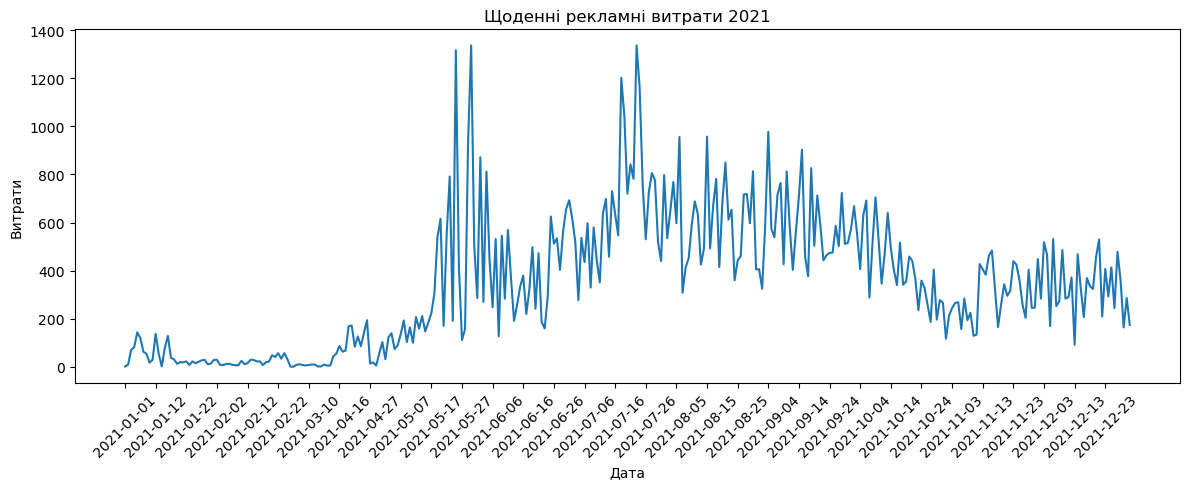

In [38]:
plt.figure(figsize=(12, 5))
plt.plot(daily_spends['ad_date'], daily_spends['daily_spend'])
plt.title('Щоденні рекламні витрати 2021')
plt.xlabel('Дата')
plt.ylabel('Витрати')
plt.xticks(daily_spends['ad_date'][: :10], rotation=45)    #не кожен день, а кожні 10 днів
plt.tight_layout()
plt.show()

In [39]:
daily_spends['rolling_7'] = (daily_spends['daily_spend'].rolling(window = 7).mean())      #БОНУСНЕ
daily_spends.head()

,ad_date,daily_spend,rolling_7
0,2021-01-01,0.39,NaN
1,2021-01-02,7.74,NaN
2,2021-01-04,70.06,NaN
3,2021-01-05,81.15,NaN
4,2021-01-06,142.77,NaN


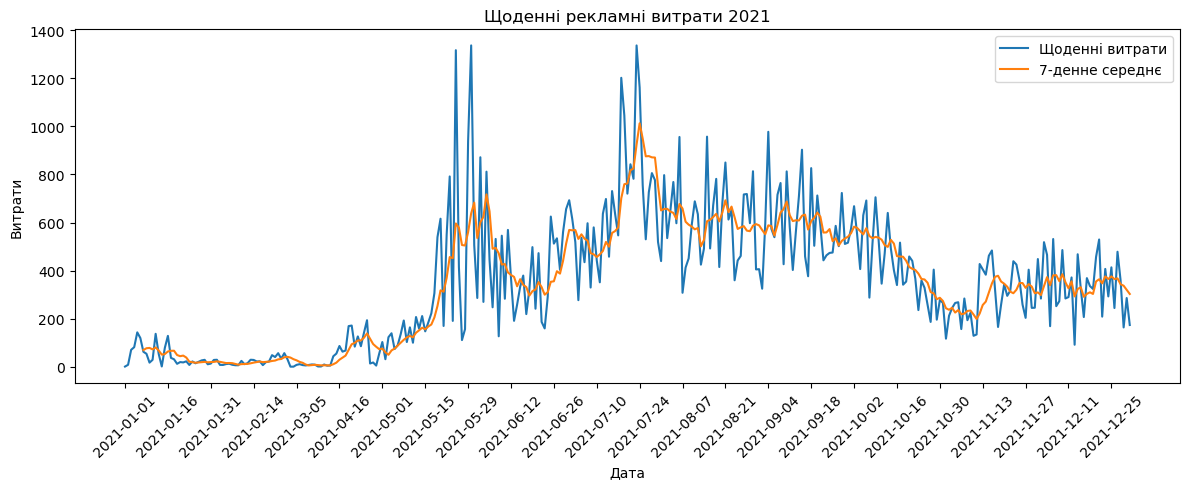

In [41]:
plt.figure(figsize=(12, 5))                                             #БОНУСНЕ
plt.plot(daily_spends['ad_date'], daily_spends['daily_spend'], label='Щоденні витрати')
plt.plot(daily_spends['ad_date'], daily_spends['rolling_7'], label='7-денне середнє')

plt.title('Щоденні рекламні витрати 2021')
plt.xlabel('Дата')
plt.ylabel('Витрати')
plt.xticks(daily_spends['ad_date'][::14], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [49]:
df_campaign_sp = df_2021.groupby('campaign_name', observed = True)['total_spend'].sum().reset_index()
df_camp_sp_all_years = df.groupby('campaign_name', observed = True)['total_spend'].sum().reset_index() #ЗА ВСІ РОКИ
df_campaign_sp.head(15) 
#df_camp_sp_all_years.head(15)

,campaign_name,total_spend
0,Brand,421.64
1,Crazy discounts,2175.29
2,Discounts,1791.22
3,Electronics,23920.42
4,Lookalike,63631.09
5,New items,2936.97
6,Promos,4993.84
7,Trendy,1234.68
8,Wholesale,14181.71


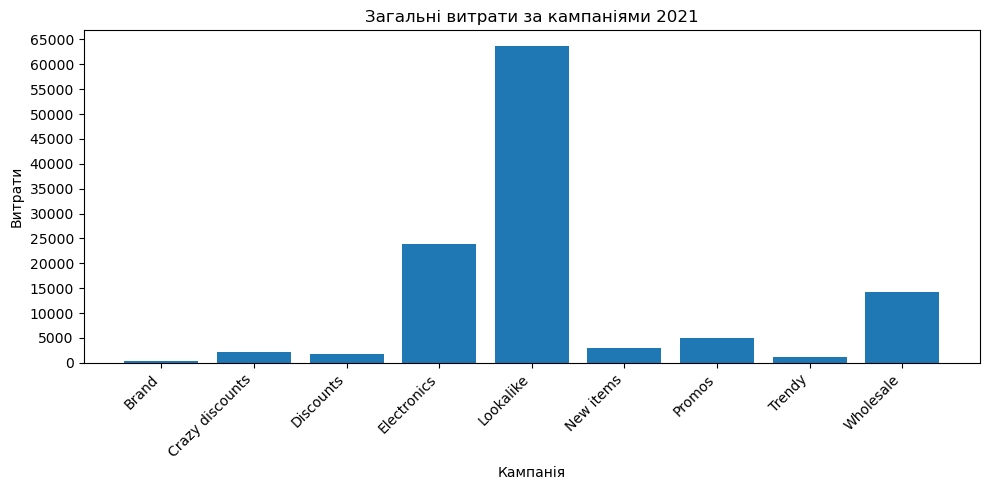

In [59]:
plt.figure(figsize=(10,5))
plt.bar(df_campaign_sp['campaign_name'], df_campaign_sp['total_spend'])
plt.title('Загальні витрати за кампаніями 2021')
plt.xlabel('Кампанія')
plt.ylabel('Витрати')
plt.xticks(rotation=45, ha='right') #ha='right' → гарне вирівнювання підписів
plt.yticks(yticks)
plt.tight_layout()
plt.show()

In [58]:
max_spend = df_campaign_sp['total_spend'].max() 
print(max_spend)
import numpy as np
yticks = np.arange(0, max_spend + 5000, 5000)
print(yticks)

63631.09
[    0.  5000. 10000. 15000. 20000. 25000. 30000. 35000. 40000. 45000.
 50000. 55000. 60000. 65000.]


In [65]:
camp_romi = (df_2021.groupby('campaign_name', observed = True)[['total_spend', 'total_value']].sum().reset_index())

camp_romi.head(15)

,campaign_name,total_spend,total_value
0,Brand,421.64,518.67
1,Crazy discounts,2175.29,2583.59
2,Discounts,1791.22,2196.60
3,Electronics,23920.42,29169.38
4,Lookalike,63631.09,80234.70
5,New items,2936.97,3742.05
6,Promos,4993.84,8793.77
7,Trendy,1234.68,2326.05
8,Wholesale,14181.71,17421.33


In [86]:
camp_romi['romi'] = ((camp_romi['total_value'] - camp_romi['total_spend']) / camp_romi['total_spend']) #РАХУЮ РОМІ ОКРЕМО, БО В "РІДНІЙ" КОЛОНЦІ РОМІ Є НАН, НЕ ХОЧУ ЗАМІНЯТИ ЇХ
camp_romi.head(10)

,campaign_name,total_spend,total_value,romi
0,Brand,421.64,518.67,0.230125
1,Crazy discounts,2175.29,2583.59,0.187699
2,Discounts,1791.22,2196.60,0.226315
3,Electronics,23920.42,29169.38,0.219434
4,Lookalike,63631.09,80234.70,0.260935
5,New items,2936.97,3742.05,0.274119
6,Promos,4993.84,8793.77,0.760923
7,Trendy,1234.68,2326.05,0.883929
8,Wholesale,14181.71,17421.33,0.228436


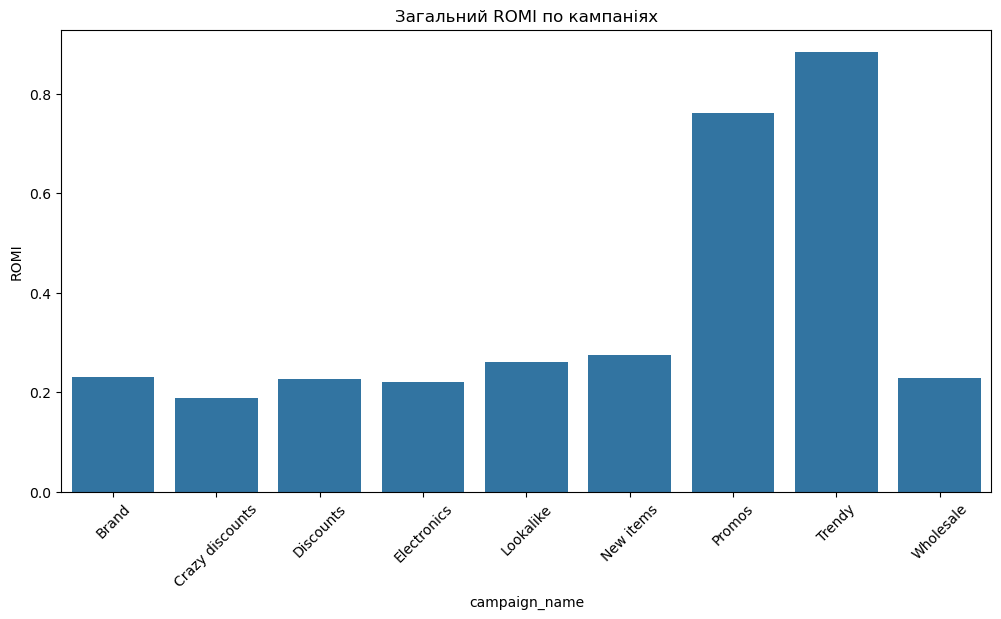

In [70]:
plt.figure(figsize=(12,6))
sns.barplot(x='campaign_name', y='romi', data=camp_romi)
plt.xticks(rotation=45)
plt.title("Загальний ROMI по кампаніях")
plt.ylabel("ROMI")
plt.show()

In [107]:
 #ТРЕБА ВСУНУТИ КОЛОНКУ З КАМПАНІЯМИ У DAILY ROMI2 ДЛЯ ПОБУДОВИ БОКСПЛОТУ ЩОДЕННОГО РОМІ
daily_romi2 = df_2021.groupby('ad_date', observed = True)[['total_spend','total_value','campaign_name']].sum().reset_index()

daily_romi2['romi'] = ((daily_romi2['total_value'] - daily_romi2['total_spend']) / daily_romi2['total_spend'])
daily_romi2.head()

,ad_date,total_spend,total_value,campaign_name,romi
0,2021-01-01,0.39,0.59,BrandDiscounts,0.512821
1,2021-01-02,7.74,6.90,Discounts,-0.108527
2,2021-01-04,70.06,68.47,Discounts,-0.022695
3,2021-01-05,81.15,61.68,Discounts,-0.239926
4,2021-01-06,142.77,145.97,BrandDiscounts,0.022414


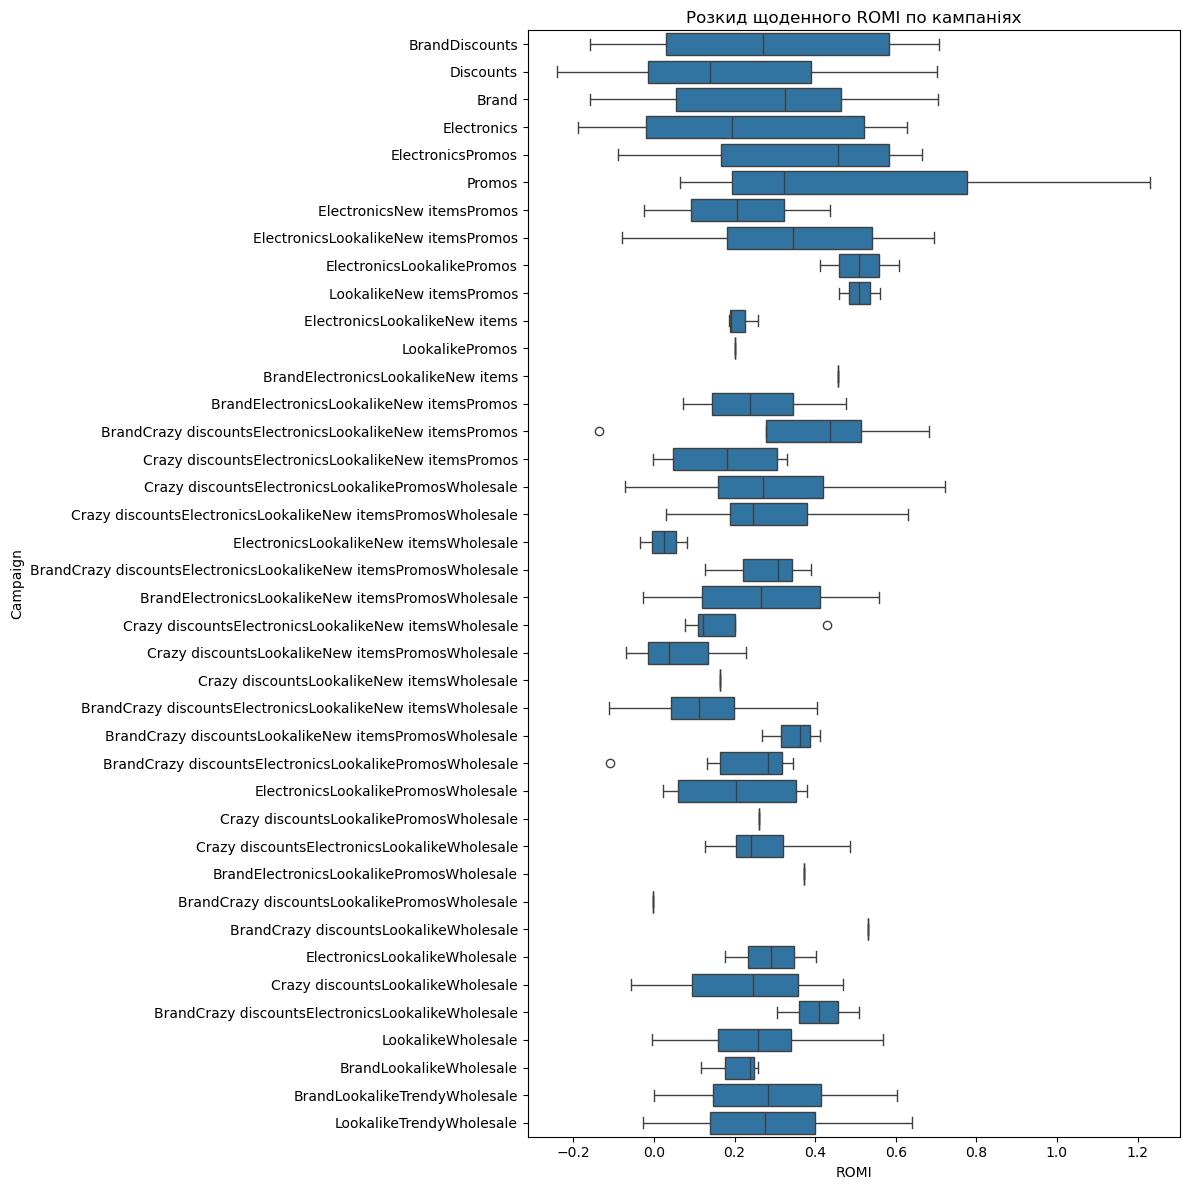

In [110]:

plt.figure(figsize=(12, 12))
sns.boxplot(y='campaign_name', x='romi', data=daily_romi2)
plt.title("Розкид щоденного ROMI по кампаніях")
plt.xlabel("ROMI")
plt.ylabel("Campaign")
plt.tight_layout()
plt.show()

In [5]:
df[['total_spend', 'total_value', 'romi']].isna().sum()


total_spend     0
total_value     0
romi           32
dtype: int64

In [7]:
# У ВИТРАТАХ І ПРИБУТКУ НЕМАЄ ПОРОЖНІХ КОМІРОК, Є ТІЛЬКИ В ROMI. ЗНАЧИТЬ, ВІН НЕ ПОРАХОВАНИЙ, БУДУ ЗАПОВНЮВАТИ ПОРОЖНІ КОМІРКИ ФОРМУЛОЮ РОЗРАХУНКУ ROMI
df['romi'] = df['romi'].fillna((df['total_value'] - df['total_spend']) / df['total_spend'])
df['romi'].isna().sum()
#ВСЕ ОДНО 32 ЗНАЧЕННЯ НАН

np.int64(32)

In [8]:
#ЗНАЧИТЬ, ПЕРЕВІРЯЄМО, ЩО В ІНШИХ СТОВПЦЯХ ТАМ, ДЕ В РОМІ НАН
df.loc[df['romi'].isna(), ['total_value', 'total_spend']]
#ВСЮДИ 0.0 - ЗНАЧИТЬ, ЗНАЧЕННЯМИ МОЖНА ЗНЕХТУВАТИ - НУЛЬ ПРИБУТКУ, НУЛЬ ВИТРАТ

,total_value,total_spend
0,0.0,0.0
1,0.0,0.0
11,0.0,0.0
14,0.0,0.0
16,0.0,0.0
18,0.0,0.0
20,0.0,0.0
247,0.0,0.0
248,0.0,0.0
249,0.0,0.0


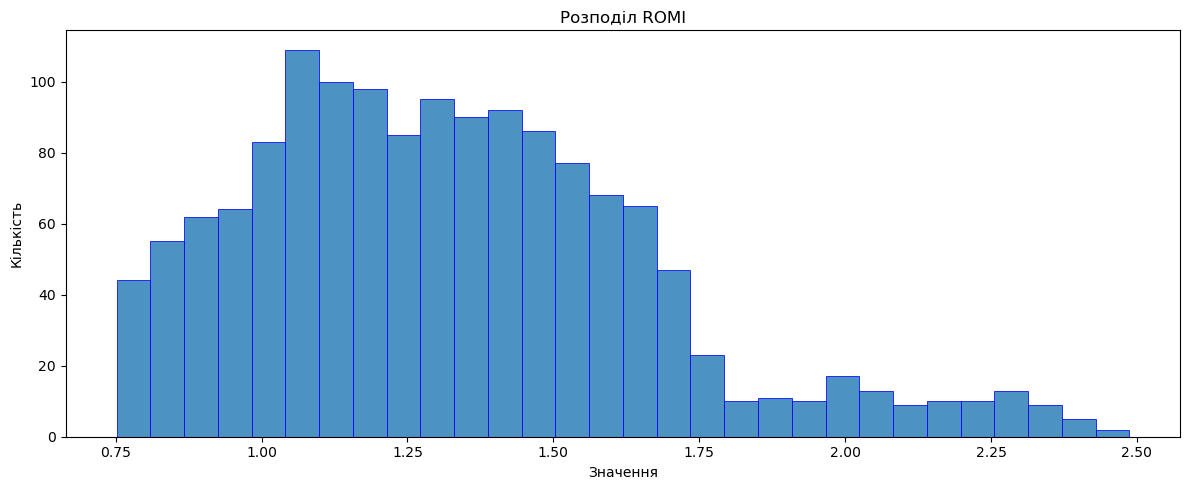

In [20]:
#НЕХТУЄМО РОМІ ДЛЯ ЧИСТОТИ ГІСТОГРАМИ
clean_romi = df[df['romi'].notna()]
plt.figure(figsize=(12, 5))                                             
plt.hist(clean_romi['romi'], bins=30, edgecolor='blue', linewidth=0.7, alpha=0.8)
plt.title('Розподіл ROMI')
plt.xlabel('Значення')
plt.ylabel('Кількість')
plt.tight_layout()
plt.show()
#Більшість значень між 1 та 1.25 - більшість кампаній виходить у помірну плюсову дохідність, довгий правий хвіст - суперуспішні кампанії, їх небагато, але є, це добре)

In [34]:
numerics = ['total_spend', 'total_impressions', 'total_clicks', 'total_value', 'cpc', 'cpm', 'ctr', 'romi']
df_numerics = df[numerics]
df_numerics[['cpc','cpm', 'ctr']].isna().sum()
df_numerics[['cpc','cpm', 'ctr','romi']] = df_numerics[['cpc','cpm', 'ctr','romi']].fillna(0)
df_numerics.head()

C:\Users\Iryna\AppData\Local\Temp\ipykernel_29364\742886076.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_numerics[['cpc','cpm', 'ctr','romi']] = df_numerics[['cpc','cpm', 'ctr','romi']].fillna(0)


,total_spend,total_impressions,total_clicks,total_value,cpc,cpm,ctr,romi
0,0.00,0,0,0.00,0.00,0.00,0.000000,0.000000
1,0.00,0,0,0.00,0.00,0.00,0.000000,0.000000
2,227.45,6054,58,191.87,3.92,37.57,0.009580,0.843570
3,335.91,27562,69,472.61,4.87,12.19,0.002503,1.406954
4,714.03,33358,115,680.34,6.21,21.41,0.003447,0.952817


In [35]:
corr_matrix = df_numerics.corr()
print(corr_matrix)

                   total_spend  total_impressions  total_clicks  total_value  \
total_spend           1.000000           0.475607      0.480066     0.978890   
total_impressions     0.475607           1.000000      0.765489     0.472037   
total_clicks          0.480066           0.765489      1.000000     0.472124   
total_value           0.978890           0.472037      0.472124     1.000000   
cpc                   0.269575          -0.079259     -0.146827     0.258207   
cpm                   0.486300          -0.109387     -0.023651     0.475645   
ctr                  -0.013313          -0.138378      0.210532    -0.010272   
romi                 -0.055106          -0.029942     -0.040042     0.032000   

                        cpc       cpm       ctr      romi  
total_spend        0.269575  0.486300 -0.013313 -0.055106  
total_impressions -0.079259 -0.109387 -0.138378 -0.029942  
total_clicks      -0.146827 -0.023651  0.210532 -0.040042  
total_value        0.258207  0.475645 -

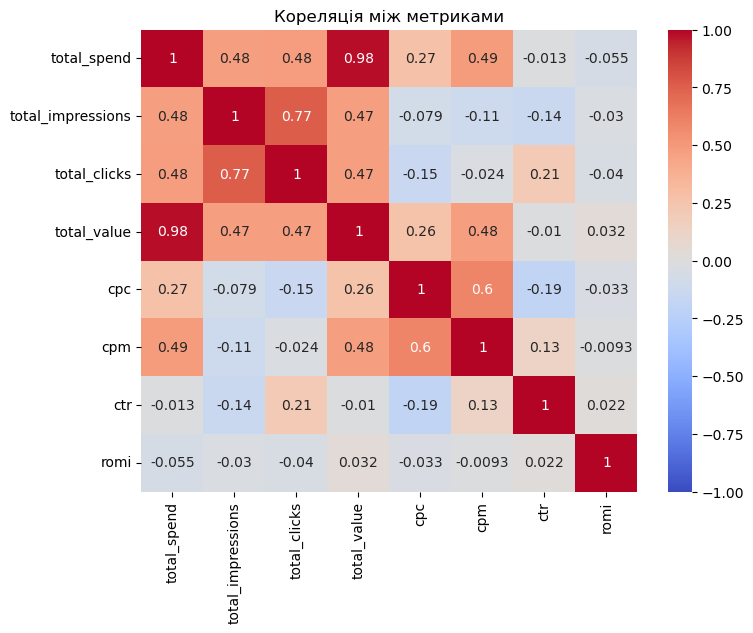

In [37]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Кореляція між метриками")
plt.show()
#Які показники мають найвищу та найнижчу кореляцію?

#Найвищу кореляцію (0.98-0.47) мають total_value з total_spend, total_impr з total_clicks, total_value з cpm та total_spend з cpm, 
##cpm з cpc (тут цікаво: виходить, чим дорожче 1000 показів реклам, тим більше клікають)
#Найнижча кореляція(-0.0 - -0.19) всюди у ромі, бо це розрахункове значення
#а також колонка ctr має багато низьких значень(багатьом глядачам не цікава реклама)
#total_imp трохи падає, коли ростуть cpc та cpm

#З чим корелює "total_value"?

#total_value корелює позитивно з total spend(чим більше в кампанію вклалися - тим більше прибутку вона принесла), 
#total impressions та total clicks(чим більше переглядів і кліків - тим вище прибуток), 
#із cpm (чим дорожче показувати рекламу - тим більше дохідність)
#немає кореляції прибутку з тим, чи цікава реклама глядачам(ctr)

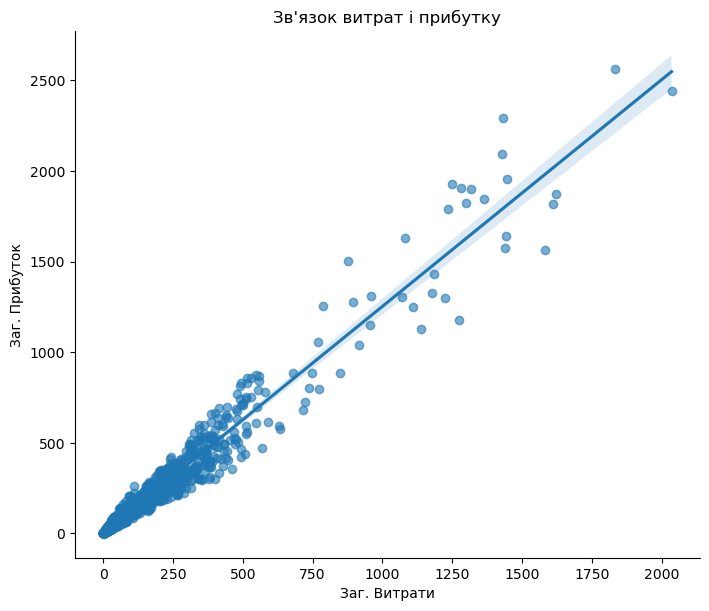

In [38]:
sns.lmplot(data=df_numerics, x='total_spend', y='total_value', height=6,    aspect=1.2,  scatter_kws={'alpha':0.6}  )
plt.title("Зв'язок витрат і прибутку")
plt.xlabel("Заг. Витрати")
plt.ylabel("Заг. Прибуток")
plt.show()
#Доводить найбільший рівень кореляції витрат і прибутку. Більше вкладаєш - більше маєш
#Точки, які найдалі від прямої зверху прямої - випадки з надвеликим прибутком, позитивні викиди, а надто нижче прямої - викиди з великими витратами відносно середніх значень